In [1]:
!pip install -q biopython openpyxl plotly kaleido fair-esm transformers sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 638.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 15.7 MB/s eta 0:00:00


In [16]:
import glob
import io
import json
import os
import re
from typing import Optional

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import plotly.colors as pc
import plotly.graph_objects as go
import torch
from Bio import SeqIO
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

import re, time, json, urllib.request
from pathlib import Path
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM, T5Tokenizer, T5EncoderModel


DEV = "cuda" if torch.cuda.is_available() else "cpu"
from google.colab import drive; drive.mount("/content/drive")
OUT = Path("/content/drive/MyDrive/ala_scan"); OUT.mkdir(parents=True, exist_ok=True)
print(DEV)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu


In [4]:
from google.colab import drive
drive.mount("/content/drive")
OUT = Path("/content/drive/MyDrive/ala_scan"); OUT.mkdir(parents=True, exist_ok=True)
print(DEVICE, "|", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu | /content/drive/MyDrive/ala_scan


In [5]:
_CACHE = {}

def get_model(kind, name):
    if (kind, name) not in _CACHE:
        if kind == "esm2":
            from transformers import AutoTokenizer, AutoModel
            tok, m = AutoTokenizer.from_pretrained(name), AutoModel.from_pretrained(name, output_hidden_states=True)
        else:
            from transformers import T5Tokenizer, T5EncoderModel
            tok, m = T5Tokenizer.from_pretrained(name, do_lower_case=False), T5EncoderModel.from_pretrained(name, output_hidden_states=True)
        _CACHE[(kind, name)] = (tok, m.float().eval().to(DEVICE))
        print("loaded", name)
    return _CACHE[(kind, name)]

@torch.no_grad()
def embed_esm2(seqs, name="facebook/esm2_t33_650M_UR50D"):
    """-> list of (layers, n_res, dim); CLS and EOS dropped."""
    tok, model = get_model("esm2", name)
    enc = tok(seqs, return_tensors="pt", padding=True)
    mask = enc["attention_mask"]
    hs = model(**{k: v.to(DEVICE) for k, v in enc.items()}).hidden_states
    return [torch.stack([h[b, 1:int(mask[b].sum())-1] for h in hs]).float()
            for b in range(len(seqs))]

@torch.no_grad()
def embed_prostt5(seqs, name="Rostlab/ProstT5", direction="<AA2fold>"):
    """-> list of (layers, n_res, dim); prefix token and EOS dropped."""
    tok, model = get_model("prostt5", name)
    prep = [direction + " " + " ".join(re.sub(r"[UZOB]", "X", s).upper()) for s in seqs]
    enc = tok(prep, return_tensors="pt", padding="longest", add_special_tokens=True)
    mask = enc["attention_mask"]
    hs = model(**{k: v.to(DEVICE) for k, v in enc.items()}).hidden_states
    return [torch.stack([h[b, 1:int(mask[b].sum())-1] for h in hs]).float()
            for b in range(len(seqs))]

In [8]:
SOURCE = "pdb"          # "pdb" | "uniprot" | "paste"
PDB_ID, CHAIN = "1ERE", "A"
UNIPROT, PASTED = "P03372", ""

def seq_from_pdb(pdb_id, chain):
    txt = urllib.request.urlopen(f"https://www.rcsb.org/fasta/entry/{pdb_id.upper()}").read().decode()
    for blk in txt.split(">")[1:]:
        head, *body = blk.strip().splitlines()
        if chain is None or chain.upper() in head.split("|")[1].upper():
            print(head[:80]); return "".join(body).upper()
    raise ValueError("chain not found")

if SOURCE == "pdb":
    SEQ = seq_from_pdb(PDB_ID, CHAIN)
elif SOURCE == "uniprot":
    txt = urllib.request.urlopen(f"https://rest.uniprot.org/uniprotkb/{UNIPROT}.fasta").read().decode()
    SEQ = "".join(l.strip() for l in txt.splitlines() if not l.startswith(">")).upper()
else:
    SEQ = "".join(PASTED.split()).upper()

N = len(SEQ)
print(N, "residues |", SEQ[:60])

1ERE_1|Chains A, B, C, D, E, F|ESTROGEN RECEPTOR|Homo sapiens (9606)
253 residues | SKKNSLALSLTADQMVSALLDAEPPILYSEYDPTRPFSEASMMGLLTNLADRELVHMINW


In [19]:
PDB_ID, CHAIN = "1ERE", "A"          # or set UNIPROT below instead
UNIPROT = "P03372"                      # e.g. "P03372"

if UNIPROT:
    txt = urllib.request.urlopen(f"https://rest.uniprot.org/uniprotkb/{UNIPROT}.fasta").read().decode()
    SEQ_UNIPROT = "".join(l for l in txt.splitlines()[1:])
if PDB_ID:
    txt = urllib.request.urlopen(f"https://www.rcsb.org/fasta/entry/{PDB_ID}").read().decode()
    for blk in txt.split(">")[1:]:
        head, *body = blk.strip().splitlines()
        if CHAIN in head.split("|")[1]:
            SEQ_PDB = "".join(body); break
SEQ=SEQ_UNIPROT

SEQ = SEQ.upper().strip()
N = len(SEQ)
print(N, "residues:", SEQ[:60])

595 residues: MTMTLHTKASGMALLHQIQGNELEPLNRPQLKIPLERPLGEVYLDSSKPAVYNYPEGAAY


In [20]:
# fetch both, then
from difflib import SequenceMatcher
m = SequenceMatcher(None, SEQ_UNIPROT, SEQ_PDB, autojunk=False).find_longest_match()
print(f"PDB[{m.b}:{m.b+m.size}] == UniProt[{m.a}:{m.a+m.size}]  ({m.size} aa)")
print(f"offset: PDB position i  ->  UniProt residue i + {m.a - m.b}")
print("PDB-only head:", repr(SEQ_PDB[:m.b]), " tail:", repr(SEQ_PDB[m.b+m.size:]))

PDB[0:253] == UniProt[300:553]  (253 aa)
offset: PDB position i  ->  UniProt residue i + 300
PDB-only head: ''  tail: ''


In [21]:
WINDOWS, MUT, BATCH = [5, 7, 9, 11], "A", 4

def esm2(model,seqs, _c={}):
    """-> list of (layers, residues, dim), special tokens removed."""
    if not _c:
        _c["t"] = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
        _c["m"] = AutoModel.from_pretrained("facebook/esm2_t33_650M_UR50D",
                                            output_hidden_states=True).eval().to(DEV)
    e = _c["t"](seqs, return_tensors="pt", padding=True)
    with torch.no_grad():
        hs = _c["m"](**{k: v.to(DEV) for k, v in e.items()}).hidden_states
    return [torch.stack([h[b, 1:int(e["attention_mask"][b].sum())-1] for h in hs]).float()
            for b in range(len(seqs))]

def prostt5(seqs, _c={}):
    if not _c:
        _c["t"] = T5Tokenizer.from_pretrained("Rostlab/ProstT5", do_lower_case=False)
        _c["m"] = T5EncoderModel.from_pretrained("Rostlab/ProstT5",
                                                 output_hidden_states=True).float().eval().to(DEV)
    p = ["<AA2fold> " + " ".join(re.sub(r"[UZOB]", "X", s)) for s in seqs]
    e = _c["t"](p, return_tensors="pt", padding="longest")
    with torch.no_grad():
        hs = _c["m"](**{k: v.to(DEV) for k, v in e.items()}).hidden_states
    return [torch.stack([h[b, 1:int(e["attention_mask"][b].sum())-1] for h in hs]).float()
            for b in range(len(seqs))]
MODELS = {
    "esm2_150M": make_esm2("facebook/esm2_t30_150M_UR50D"),
    "esm2_650M": make_esm2("facebook/esm2_t33_650M_UR50D"),
    "prostt5":   prostt5,
}

MODELS = {"esm2": esm2, "prostt5": prostt5}

def win(H, p, w):                      # (layers, dim): mean over window centred on p
    return H[:, max(0, p-w//2):min(N, p+w//2+1)].mean(1)

pos_list = [i for i, a in enumerate(SEQ) if a != MUT]
WT = {k: f([SEQ])[0] for k, f in MODELS.items()}
dis = {k: {w: np.full((WT[k].shape[0], N), np.nan, np.float32) for w in WINDOWS} for k in MODELS}
for k in MODELS: print(k, tuple(WT[k].shape), "= (layers, residues, dim)")

t0 = time.time()
for s in range(0, len(pos_list), BATCH):
    sub  = pos_list[s:s+BATCH]
    muts = [SEQ[:p] + MUT + SEQ[p+1:] for p in sub]       # each mutant needs its own pass
    for k, f in MODELS.items():
        for p, H in zip(sub, f(muts)):
            for w in WINDOWS:
                dis[k][w][:, p] = (1 - F.cosine_similarity(win(WT[k], p, w), win(H, p, w), -1)).cpu()
    print(f"\r{s+len(sub)}/{len(pos_list)}  {time.time()-t0:.0f}s", end="")

np.savez_compressed(OUT/"disruption.npz",
                    **{f"{k}_w{w}": dis[k][w] for k in MODELS for w in WINDOWS})
print("\nsaved")

Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

esm2 (34, 595, 1280) = (layers, residues, dim)
prostt5 (25, 595, 1024) = (layers, residues, dim)


/tmp/ipykernel_2689/2233677492.py:44: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  dis[k][w][:, p] = (1 - F.cosine_similarity(win(WT[k], p, w), win(H, p, w), -1)).cpu()


548/548  1800s
saved


Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

/tmp/ipykernel_2689/3731828364.py:11: RuntimeWarning: Mean of empty slice
  return np.nanmean((m - np.nanmean(m,1,keepdims=True))/(np.nanstd(m,1,keepdims=True)+1e-12), 0)
/tmp/ipykernel_2689/3731828364.py:13: RuntimeWarning: Mean of empty slice
  prof = {k: np.nanmean([z(dis[k][w]) for w in WINDOWS], 0) for k in MODELS}
/tmp/ipykernel_2689/3731828364.py:16: RuntimeWarning: Mean of empty slice
  cons = np.nanmean([(v-np.nanmean(v))/np.nanstd(v) for v in prof.values()], 0)


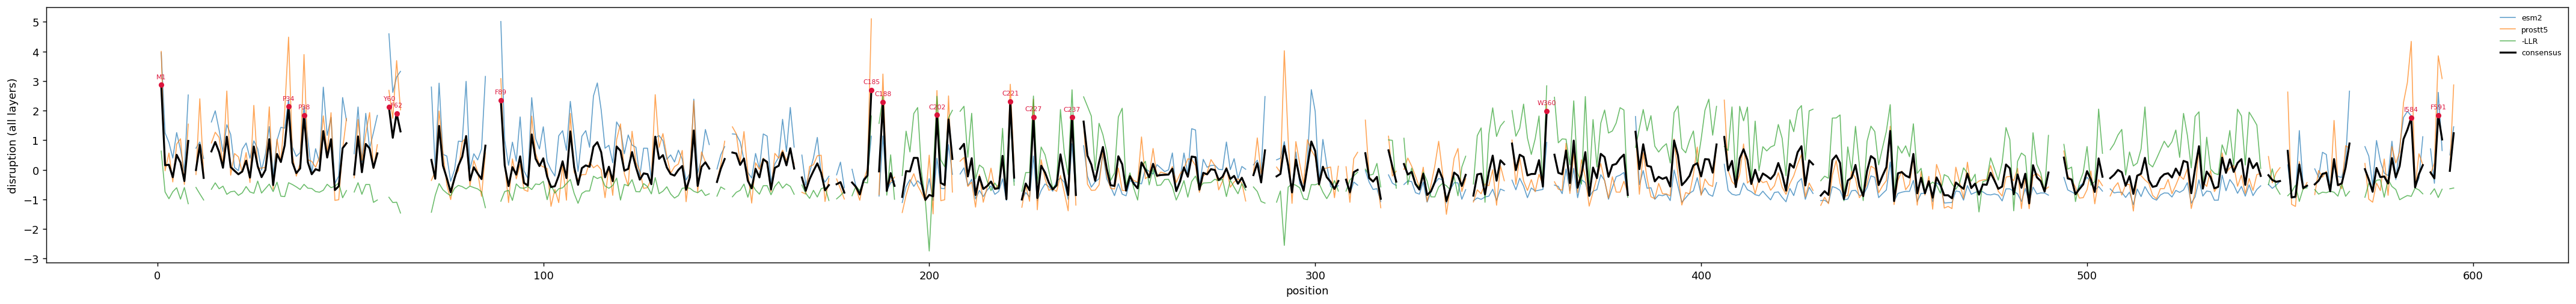

top: ['M1', 'C185', 'F89', 'C221', 'C188', 'P34', 'Y60', 'W360', 'F62', 'C202', 'P38', 'F591', 'C227', 'C237', 'I584']


In [22]:
# one extra forward pass: log P(A) - log P(wt) at every position
tk = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
lm = AutoModelForMaskedLM.from_pretrained("facebook/esm2_t33_650M_UR50D").eval().to(DEV)
with torch.no_grad():
    lp = torch.log_softmax(lm(**tk(SEQ, return_tensors="pt").to(DEV)).logits[0], -1)[1:N+1]
llr = np.array([float(lp[i, tk.convert_tokens_to_ids(MUT)] - lp[i, tk.convert_tokens_to_ids(a)])
                if a != MUT else np.nan for i, a in enumerate(SEQ)], np.float32)
del lm; torch.cuda.empty_cache()

def z(m):   # z-score each layer, then average -> all layers combined
    return np.nanmean((m - np.nanmean(m,1,keepdims=True))/(np.nanstd(m,1,keepdims=True)+1e-12), 0)

prof = {k: np.nanmean([z(dis[k][w]) for w in WINDOWS], 0) for k in MODELS}
prof["-LLR"] = -llr
pos = np.arange(1, N+1)
cons = np.nanmean([(v-np.nanmean(v))/np.nanstd(v) for v in prof.values()], 0)
top = np.argsort(np.nan_to_num(cons, nan=-9e9))[::-1][:15]

plt.figure(figsize=(max(10, N/18), 4), dpi=130)
for k, v in prof.items():
    plt.plot(pos, (v-np.nanmean(v))/np.nanstd(v), lw=.9, alpha=.7, label=k)
plt.plot(pos, cons, lw=1.8, c="k", label="consensus")
plt.scatter(pos[top], cons[top], s=16, c="crimson", zorder=5)
for i in top:
    plt.annotate(f"{SEQ[i]}{i+1}", (pos[i], cons[i]), xytext=(0,6),
                 textcoords="offset points", ha="center", fontsize=6, c="crimson")
plt.xlabel("position"); plt.ylabel("disruption (all layers)"); plt.legend(fontsize=7, frameon=False)
plt.tight_layout(); plt.savefig(OUT/"result.png", bbox_inches="tight"); plt.show()

import pandas as pd
pd.DataFrame({"position": pos, "aa": list(SEQ), **prof, "consensus": cons}).to_csv(
    OUT/"results.csv", index=False)
print("top:", [f"{SEQ[i]}{i+1}" for i in top])